# Evaluation figures

One cell per graphic. Run **Setup** first, then any figure cell.
Each cell reloads its data and re-saves its PNG into `figures/`.

In [1]:
# Setup — run this first. Then every figure cell below is independent.
import json, math
from pathlib import Path
import numpy as np, pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

BASE = Path.cwd()                       # run the notebook from output/thesis_evaluation/
assert (BASE / "data").exists(), "Run this notebook from inside output/thesis_evaluation/"
DATA = BASE / "data"
FIG  = BASE / "figures"; FIG.mkdir(exist_ok=True)
REPO = BASE.parents[1]                  # .../RIFTCast
DS   = REPO / "data/_dimpled_d30"       # rendered dataset (for figures 05 / 05b / 06)
print("DATA:", DATA, "\nFIG :", FIG, "\nDS  :", DS, "(exists:", DS.exists(), ")")

DATA: /home/timnogga/bachelorthesis/biwi_kinect_head_pose/RIFTCast/output/thesis_evaluation/data 
FIG : /home/timnogga/bachelorthesis/biwi_kinect_head_pose/RIFTCast/output/thesis_evaluation/figures 
DS  : /home/timnogga/bachelorthesis/biwi_kinect_head_pose/RIFTCast/data/_dimpled_d30 (exists: True )


## Figure 01 — depth vs RGB baseline + region split (N = 0..12)

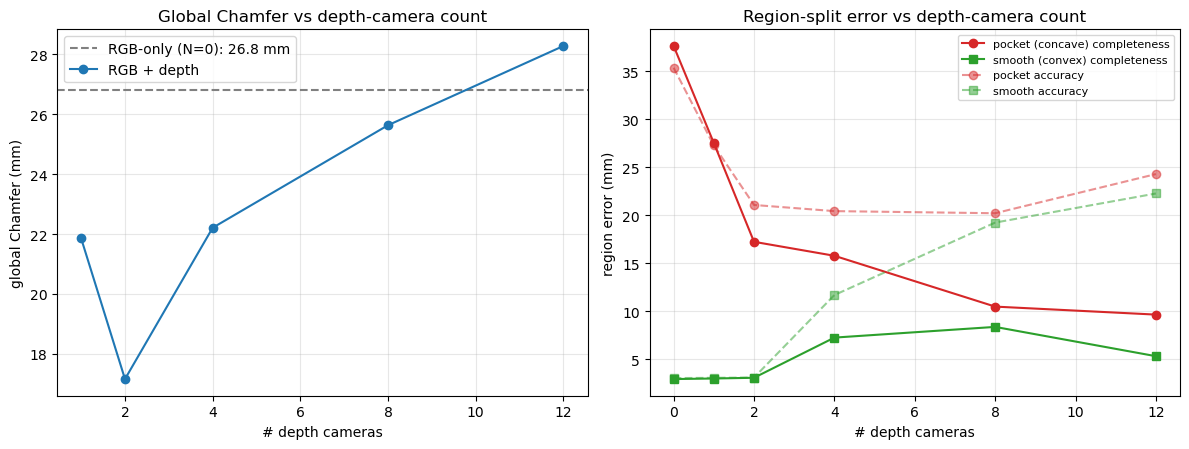

In [2]:
# Figure 01 — depth vs RGB baseline + region split (N = 0..12)
df = pd.read_csv(DATA / "metrics_N0-N12_regionsplit.csv")
N = df.num_depth.values
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
base = df.loc[df.num_depth == 0, "chamfer_mm"].iloc[0]
ax[0].axhline(base, ls="--", c="gray", label=f"RGB-only (N=0): {base:.1f} mm")
m = df.num_depth >= 1
ax[0].plot(df.num_depth[m], df.chamfer_mm[m], "o-", c="C0", label="RGB + depth")
ax[0].set_xlabel("# depth cameras"); ax[0].set_ylabel("global Chamfer (mm)")
ax[0].set_title("Global Chamfer vs depth-camera count"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(N, df.pocket_completeness_mm, "o-",  c="C3",           label="pocket (concave) completeness")
ax[1].plot(N, df.smooth_completeness_mm, "s-",  c="C2",           label="smooth (convex) completeness")
ax[1].plot(N, df.pocket_accuracy_mm,     "o--", c="C3", alpha=.5, label="pocket accuracy")
ax[1].plot(N, df.smooth_accuracy_mm,     "s--", c="C2", alpha=.5, label="smooth accuracy")
ax[1].set_xlabel("# depth cameras"); ax[1].set_ylabel("region error (mm)")
ax[1].set_title("Region-split error vs depth-camera count"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIG / "01_depth_vs_rgb_regionsplit.png", dpi=130); plt.show()

## Figure 02 — Chamfer & region split vs depth-camera count (N = 1..30)

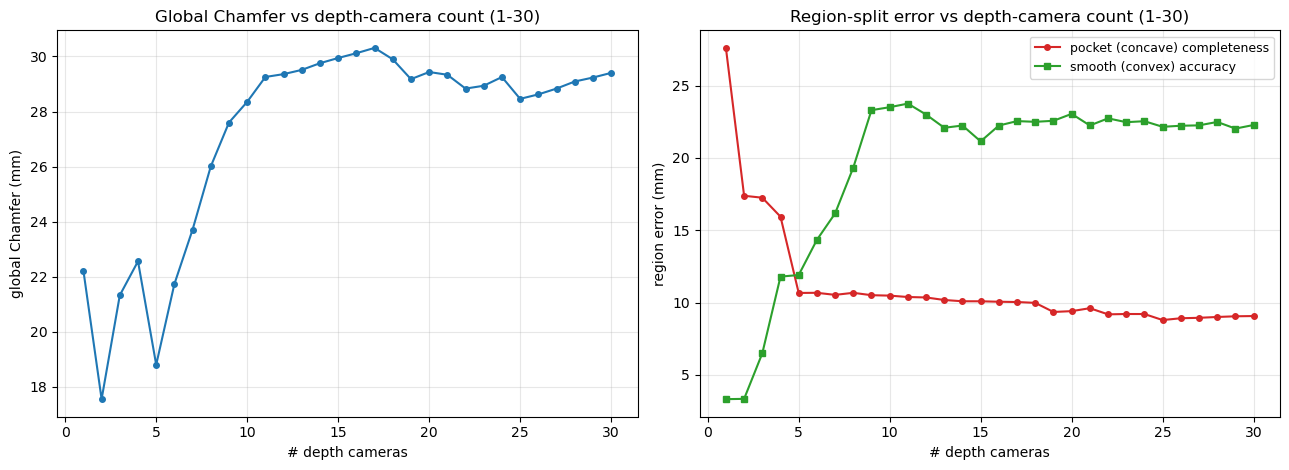

In [3]:
# Figure 02 — global Chamfer + region split vs depth-camera count (N = 1..30)
df = pd.read_csv(DATA / "sweep_1to30_binarygate.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(df.num_depth, df.chamfer_mm, "o-", c="C0", ms=4)
ax[0].set_xlabel("# depth cameras"); ax[0].set_ylabel("global Chamfer (mm)")
ax[0].set_title("Global Chamfer vs depth-camera count (1-30)"); ax[0].grid(alpha=.3)
ax[1].plot(df.num_depth, df.pocket_completeness_mm, "o-", c="C3", ms=4, label="pocket (concave) completeness")
ax[1].plot(df.num_depth, df.smooth_accuracy_mm,     "s-", c="C2", ms=4, label="smooth (convex) accuracy")
ax[1].set_xlabel("# depth cameras"); ax[1].set_ylabel("region error (mm)")
ax[1].set_title("Region-split error vs depth-camera count (1-30)"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIG / "02_chamfer_pocket_vs_cameras_1to30.png", dpi=130); plt.show()

## Figure 03 — incidence weighting (Curless-Levoy) vs binary grazing gate

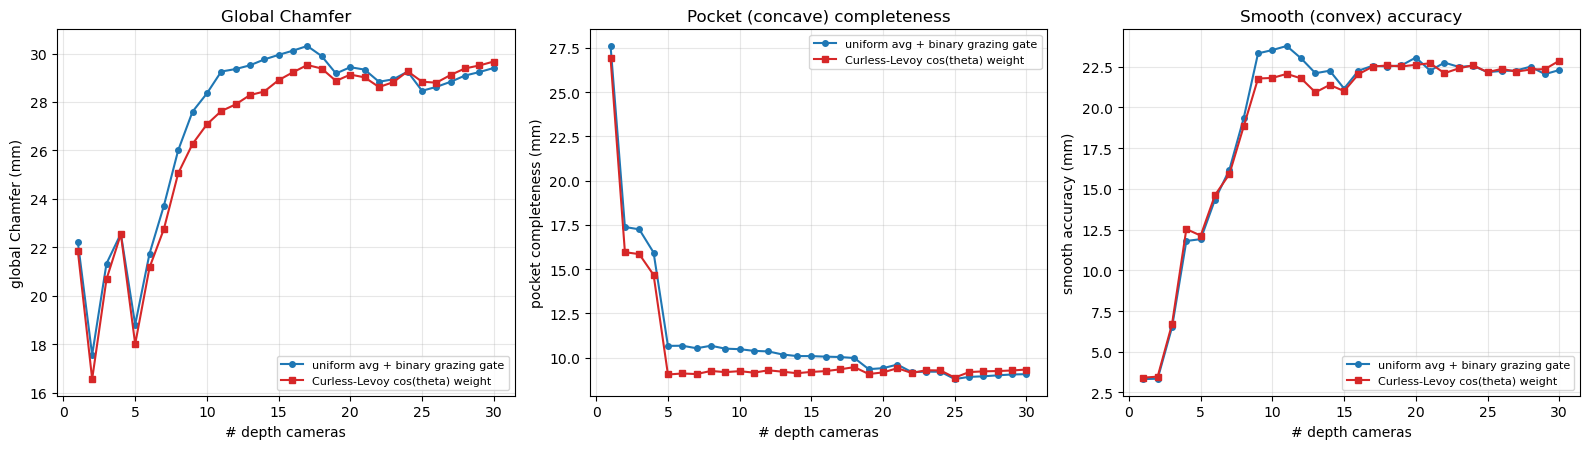

In [4]:
# Figure 03 — Curless-Levoy incidence weighting vs the binary grazing gate
a = pd.read_csv(DATA / "sweep_1to30_binarygate.csv")
b = pd.read_csv(DATA / "sweep_1to30_cosweight_p1.csv")
panels = [("chamfer_mm", "global Chamfer (mm)", "Global Chamfer"),
          ("pocket_completeness_mm", "pocket completeness (mm)", "Pocket (concave) completeness"),
          ("smooth_accuracy_mm", "smooth accuracy (mm)", "Smooth (convex) accuracy")]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for i, (col, yl, t) in enumerate(panels):
    ax[i].plot(a.num_depth, a[col], "o-", c="C0", ms=4, label="uniform avg + binary grazing gate")
    ax[i].plot(b.num_depth, b[col], "s-", c="C3", ms=4, label="Curless-Levoy cos(theta) weight")
    ax[i].set_xlabel("# depth cameras"); ax[i].set_ylabel(yl); ax[i].set_title(t)
    ax[i].grid(alpha=.3); ax[i].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / "03_incidence_weighting_vs_binarygate.png", dpi=130); plt.show()

## Figure 04 — frontal over-weighting: cos(theta)^p power sweep

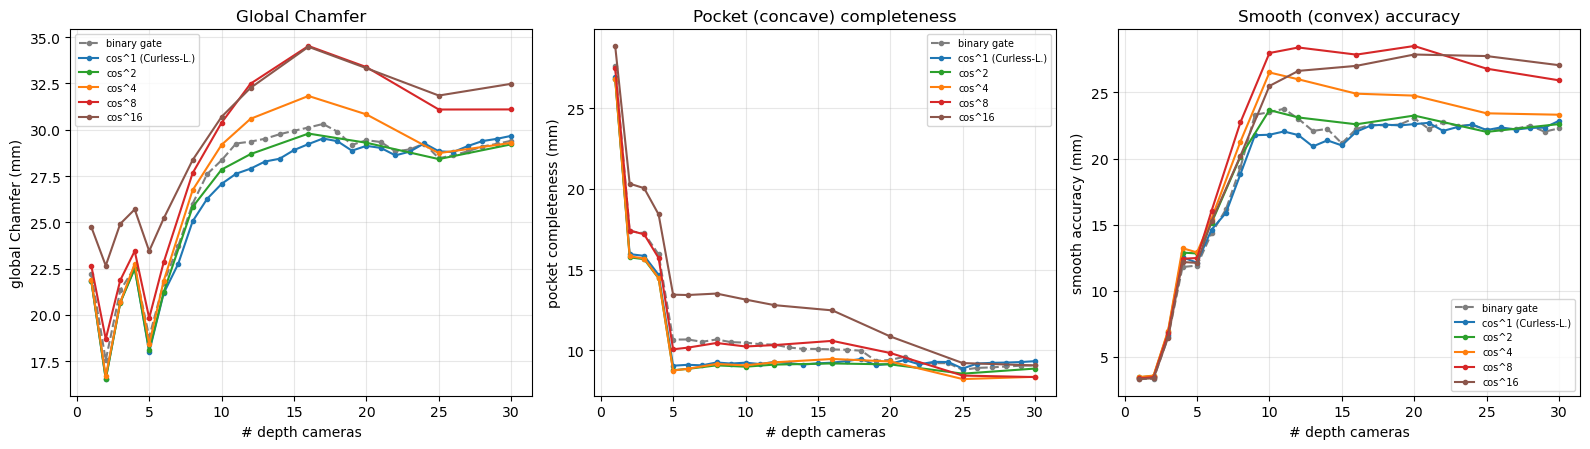

In [5]:
# Figure 04 — weighting face-on cameras harder: cos(theta)^p power sweep
series = [("binary gate",        "sweep_1to30_binarygate.csv",   "C7", "--"),
          ("cos^1 (Curless-L.)", "sweep_1to30_cosweight_p1.csv", "C0", "-"),
          ("cos^2",              "power_sweep_cos2.csv",         "C2", "-"),
          ("cos^4",              "power_sweep_cos4.csv",         "C1", "-"),
          ("cos^8",              "power_sweep_cos8.csv",         "C3", "-"),
          ("cos^16",             "power_sweep_cos16.csv",        "C5", "-")]
data = [(lab, pd.read_csv(DATA / f), c, ls) for lab, f, c, ls in series]
panels = [("chamfer_mm", "global Chamfer (mm)", "Global Chamfer"),
          ("pocket_completeness_mm", "pocket completeness (mm)", "Pocket (concave) completeness"),
          ("smooth_accuracy_mm", "smooth accuracy (mm)", "Smooth (convex) accuracy")]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for i, (col, yl, t) in enumerate(panels):
    for lab, df, c, ls in data:
        ax[i].plot(df.num_depth, df[col], ls, marker="o", ms=3, c=c, label=lab)
    ax[i].set_xlabel("# depth cameras"); ax[i].set_ylabel(yl); ax[i].set_title(t)
    ax[i].grid(alpha=.3); ax[i].legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "04_frontal_overweighting_power_sweep.png", dpi=130); plt.show()

## Figure 05 — dataset: ray-marched depth from multiple angles

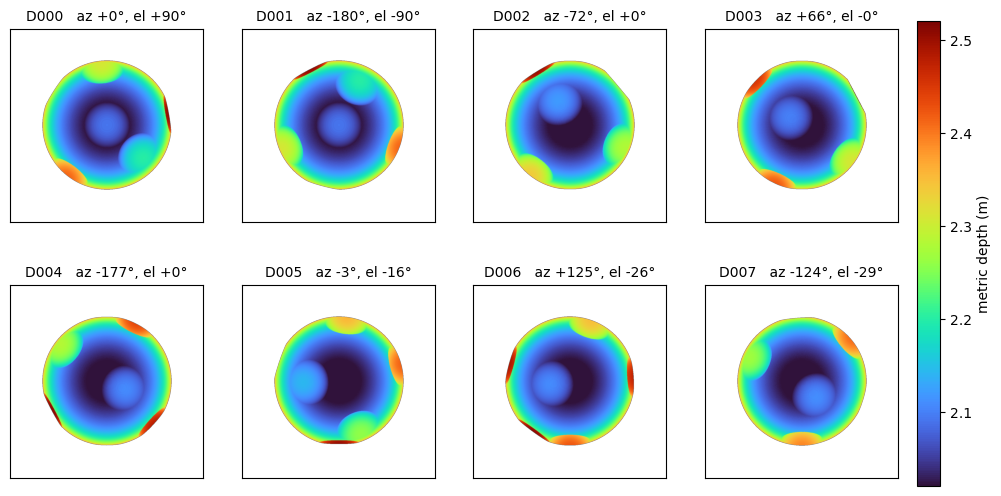

In [6]:
# Figure 05 — dataset showcase: ray-marched depth from 8 of the 30 depth cameras
CAM_IDS = ["D000", "D001", "D002", "D003", "D004", "D005", "D006", "D007"]; NCOL = 4
BG_M = 4.9; VMIN, VMAX = 2.02, 2.52; HALF = 430
cal = {c["camera_id"]: c for c in json.loads((DS / "calibration_dome.json").read_text())["cameras"]}
def az_el(p):
    x, y, z = p; r = math.sqrt(x*x + y*y + z*z)
    return math.degrees(math.atan2(x, z)), math.degrees(math.asin(y / r))
nrow = (len(CAM_IDS) + NCOL - 1) // NCOL
fig, axes = plt.subplots(nrow, NCOL, figsize=(NCOL*3.0, nrow*3.05)); axes = np.atleast_2d(axes); im = None
for k, cid in enumerate(CAM_IDS):
    ax = axes[k // NCOL][k % NCOL]
    d = cv2.imread(str(DS / f"frame_00000/depth/{cid}.png"), cv2.IMREAD_UNCHANGED).astype(np.float32) / 1000.0
    H, W = d.shape; cy, cx = H // 2, W // 2
    obj = np.ma.masked_where(d[cy-HALF:cy+HALF, cx-HALF:cx+HALF] >= BG_M, d[cy-HALF:cy+HALF, cx-HALF:cx+HALF])
    im = ax.imshow(obj, cmap="turbo", vmin=VMIN, vmax=VMAX); ax.set_facecolor("white")
    az, el = az_el(cal[cid]["extrinsics"]["position"])
    ax.set_title(f"{cid}   az {az:+.0f}°, el {el:+.0f}°", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
for k in range(len(CAM_IDS), nrow*NCOL): axes[k // NCOL][k % NCOL].axis("off")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cbar.set_label("metric depth (m)")
fig.savefig(FIG / "05_dataset_depth_views.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 05b — dataset: pocket residual (sphere curvature removed)

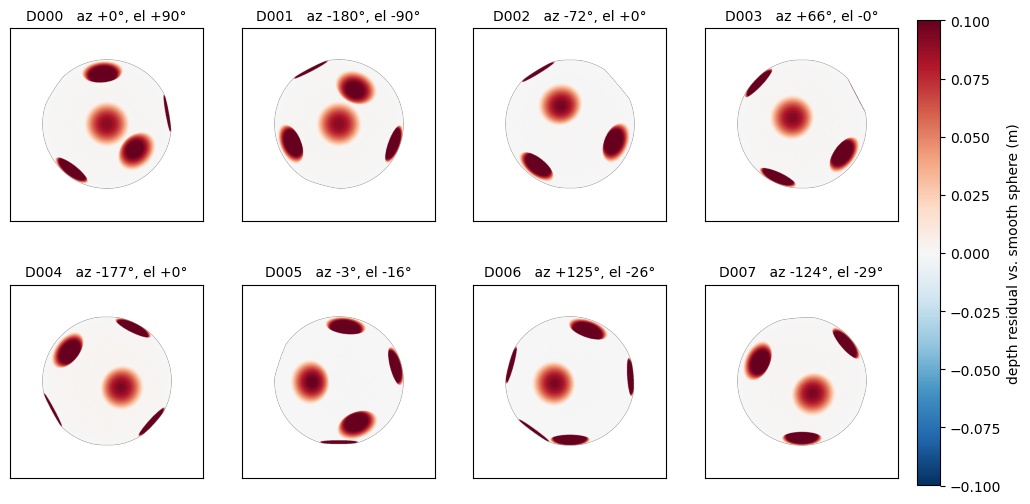

In [7]:
# Figure 05b — dataset showcase: pocket residual (smooth-sphere depth subtracted -> pockets pop)
CAM_IDS = ["D000", "D001", "D002", "D003", "D004", "D005", "D006", "D007"]; NCOL = 4
BG_M = 4.9; R = 0.5; FX = FY = 1400.0; W, H = 1920, 1080; HALF = 430; RES_MAX = 0.10
cal = {c["camera_id"]: c for c in json.loads((DS / "calibration_dome.json").read_text())["cameras"]}
cx, cy = (W-1)/2.0, (H-1)/2.0
u, v = np.meshgrid(np.arange(W, dtype=np.float32), np.arange(H, dtype=np.float32))
ray_cam = np.stack([(u-cx)/FX, (v-cy)/FY, np.ones_like(u)], 2); ray_cam /= np.linalg.norm(ray_cam, axis=2, keepdims=True)
def az_el(p):
    x, y, z = p; r = math.sqrt(x*x + y*y + z*z)
    return math.degrees(math.atan2(x, z)), math.degrees(math.asin(y / r))
def smooth_sphere_depth(cid):
    view = np.array(cal[cid]["extrinsics"]["view_matrix"], np.float32).reshape(4, 4); Rm = view[:3, :3]
    pos = np.array(cal[cid]["extrinsics"]["position"], np.float32)
    ray_w = np.einsum("hwc,cd->hwd", ray_cam, Rm); o = pos.reshape(1, 1, 3)
    b = (ray_w * o).sum(2); c = float((pos*pos).sum()) - R*R; disc = b*b - c
    depth = np.full((H, W), np.nan, np.float32); hit = disc >= 0.0
    depth[hit] = (-b[hit] - np.sqrt(disc[hit])) * ray_cam[..., 2][hit]; return depth
nrow = (len(CAM_IDS) + NCOL - 1) // NCOL
fig, axes = plt.subplots(nrow, NCOL, figsize=(NCOL*3.0, nrow*3.05)); axes = np.atleast_2d(axes); im = None
for k, cid in enumerate(CAM_IDS):
    ax = axes[k // NCOL][k % NCOL]
    d = cv2.imread(str(DS / f"frame_00000/depth/{cid}.png"), cv2.IMREAD_UNCHANGED).astype(np.float32) / 1000.0
    ref = smooth_sphere_depth(cid); resid = np.ma.masked_where(~((d < BG_M) & np.isfinite(ref)), d - ref)
    crop = resid[H//2-HALF:H//2+HALF, W//2-HALF:W//2+HALF]
    im = ax.imshow(crop, cmap="RdBu_r", vmin=-RES_MAX, vmax=RES_MAX); ax.set_facecolor("white")
    az, el = az_el(cal[cid]["extrinsics"]["position"])
    ax.set_title(f"{cid}   az {az:+.0f}°, el {el:+.0f}°", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
for k in range(len(CAM_IDS), nrow*NCOL): axes[k // NCOL][k % NCOL].axis("off")
cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02); cbar.set_label("depth residual vs. smooth sphere (m)")
fig.savefig(FIG / "05b_dataset_pocket_residual.png", dpi=150, bbox_inches="tight"); plt.show()

## Figure 06 — camera rig (30 depth + 60 RGB)

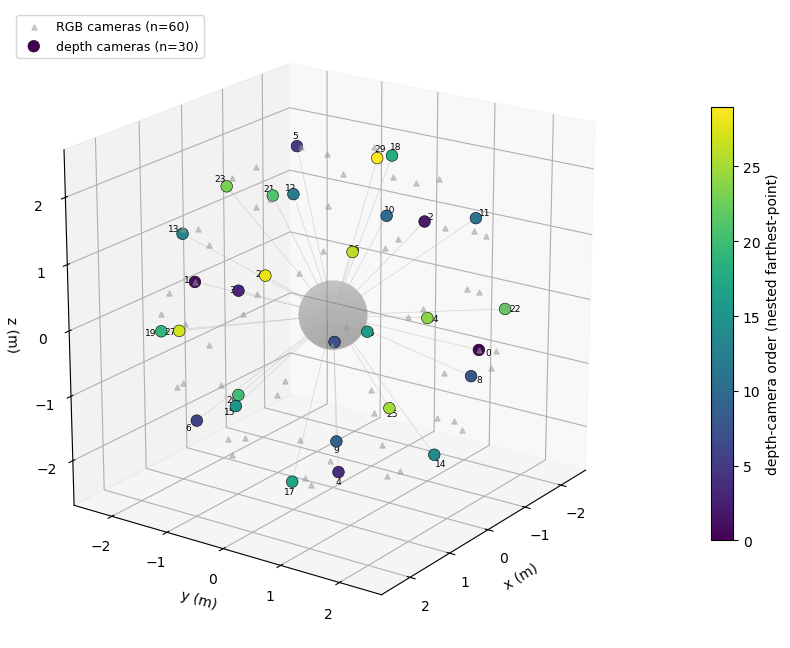

In [8]:
# Figure 06 — camera rig: 30 depth cameras (nested order) + 60 RGB cameras
from mpl_toolkits.mplot3d.art3d import Line3DCollection
R_OBJ = 0.5
cams = json.loads((DS / "calibration_dome.json").read_text())["cameras"]
rgb = np.array([c["extrinsics"]["position"] for c in cams if c["camera_type"] == "rgb"], float)
dep = [c for c in cams if c["camera_type"] == "depth"]; dep.sort(key=lambda c: int(c["camera_id"][1:]))
depp = np.array([c["extrinsics"]["position"] for c in dep], float); order = np.arange(len(depp))
fig = plt.figure(figsize=(8, 7)); ax = fig.add_subplot(111, projection="3d")
us, vs = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
ax.plot_surface(R_OBJ*np.cos(us)*np.sin(vs), R_OBJ*np.sin(us)*np.sin(vs), R_OBJ*np.cos(vs),
                color="0.6", alpha=0.25, linewidth=0, shade=True)
ax.add_collection3d(Line3DCollection([[(0, 0, 0), tuple(p)] for p in depp], colors="0.7", linewidths=0.5, alpha=0.5))
ax.scatter(rgb[:, 0], rgb[:, 1], rgb[:, 2], s=14, c="0.6", marker="^", alpha=0.45,
           label=f"RGB cameras (n={len(rgb)})", depthshade=False)
sc = ax.scatter(depp[:, 0], depp[:, 1], depp[:, 2], s=70, c=order, cmap="viridis", edgecolors="k",
                linewidths=0.4, label=f"depth cameras (n={len(depp)})", depthshade=False)
for i, p in enumerate(depp):
    ax.text(p[0]*1.06, p[1]*1.06, p[2]*1.06, str(i), fontsize=6.5, ha="center", va="center")
lim = 2.7; ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim); ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)"); ax.view_init(elev=20, azim=35)
cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.10); cbar.set_label("depth-camera order (nested farthest-point)")
ax.legend(loc="upper left", fontsize=9); fig.tight_layout()
fig.savefig(FIG / "06_camera_rig.png", dpi=150, bbox_inches="tight"); plt.show()